In [38]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

root_path = '/home/storopoli/Downloads'

train_dataset = datasets.FashionMNIST(
    root=root_path,
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root=root_path,
    train=False,
    transform=transform,
    download=True
)


In [39]:
train_dataset

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: /home/storopoli/Downloads
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [40]:
test_dataset

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: /home/storopoli/Downloads
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [41]:
from torch.utils.data import DataLoader, random_split

batch_size=32

# Dividir train_dataset em train e validation (80-20)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset_split, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(dataset=train_dataset_split, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [42]:
import torch.nn as nn

In [43]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc1 = nn.Sequential(
            nn.Linear(7 * 7 * 64, 1000),
            nn.ReLU())
        self.fc2 = nn.Linear(1000, 10)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

# Instancia o Model()
model = ConvNet()
#model.load_state_dict(torch.load('modelo_mnist.pth')) # carregar estado do modelo
print(model)

ConvNet(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=3136, out_features=1000, bias=True)
    (1): ReLU()
  )
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
)


In [44]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_parameters(model)

3199106

In [45]:
from torch.optim import Adam

# Hiperparâmetros
loss_fn = nn.CrossEntropyLoss()
learning_rate = 0.001
epochs = 6

# Instânciar o Otimizador Adam
optimizer = Adam(model.parameters(), lr=learning_rate)

# Otimizador SGD
#optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [46]:
import torch
torch.cuda.is_available()

True

In [47]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [48]:
model.to(device)

ConvNet(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=3136, out_features=1000, bias=True)
    (1): ReLU()
  )
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
)

In [49]:
total_step = len(train_loader)

# Listas para armazenar a média de cada época
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(epochs):
    # --- FASE DE TREINAMENTO ---
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Forward
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Acumulando métricas do batch
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        running_corrects += (predicted == labels).sum().item()
        total_train += labels.size(0)

        if (i + 1) % 100 == 0:
            print(f"Época [{epoch+1}/{epochs}], Step [{i+1}/{total_step}], Loss: {loss.item():.4f}")

    # Médias da época (Treino)
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects / total_train
    train_loss_history.append(epoch_train_loss)
    train_acc_history.append(epoch_train_acc)

    # --- FASE DE VALIDAÇÃO ---
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_running_corrects += (predicted == labels).sum().item()
            total_val += labels.size(0)

    # Médias da época (Validação)
    epoch_val_loss = val_running_loss / total_val
    epoch_val_acc = val_running_corrects / total_val
    val_loss_history.append(epoch_val_loss)
    val_acc_history.append(epoch_val_acc)

    print(f"\n--- Resumo Época {epoch+1} ---")
    print(f"Treino - Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f}")
    print(f"Val    - Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}\n")

Época [1/6], Step [100/1500], Loss: 0.3879
Época [1/6], Step [200/1500], Loss: 0.5413
Época [1/6], Step [300/1500], Loss: 0.7049
Época [1/6], Step [400/1500], Loss: 0.3958
Época [1/6], Step [500/1500], Loss: 0.3067
Época [1/6], Step [600/1500], Loss: 0.8482
Época [1/6], Step [700/1500], Loss: 0.4959
Época [1/6], Step [800/1500], Loss: 0.5162
Época [1/6], Step [900/1500], Loss: 0.4148
Época [1/6], Step [1000/1500], Loss: 0.1817
Época [1/6], Step [1100/1500], Loss: 0.2268
Época [1/6], Step [1200/1500], Loss: 0.4058
Época [1/6], Step [1300/1500], Loss: 0.2195
Época [1/6], Step [1400/1500], Loss: 0.3600
Época [1/6], Step [1500/1500], Loss: 0.1205

--- Resumo Época 1 ---
Treino - Loss: 0.4128, Acc: 0.8488
Val    - Loss: 0.3022, Acc: 0.8912

Época [2/6], Step [100/1500], Loss: 0.3220
Época [2/6], Step [200/1500], Loss: 0.2290
Época [2/6], Step [300/1500], Loss: 0.0655
Época [2/6], Step [400/1500], Loss: 0.1743
Época [2/6], Step [500/1500], Loss: 0.3053
Época [2/6], Step [600/1500], Loss: 0.2

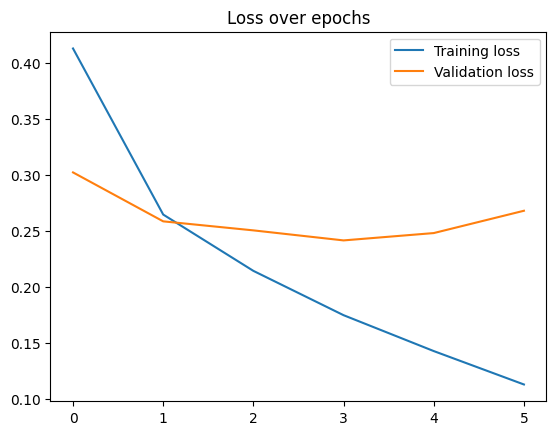

In [50]:
import matplotlib.pyplot as plt

plt.plot(train_loss_history, label='Training loss')
plt.plot(val_loss_history, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

In [51]:
model.eval() # coloca o modelo em modo de avaliação (sem calcular gradientes)

with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        # Feed-forward com as imagens de teste
        outputs = model(images)

        # gera predições usando a função max()
        _, predicted = torch.max(outputs.data, 1)

        # Acumula total e corretas
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Acurácia do Modelo em 10k imagens de teste: {round((correct / total) * 100, 3)}")

Acurácia do Modelo em 10k imagens de teste: 91.01
